# Ensembles and devices

Parameter scans and seed studies run fastest as ensembles: every device
advances complete, independent cases with no communication inside the time
loop. This tutorial splits one host CPU into four JAX devices, so the
committed outputs reproduce on any laptop. The same code drives GPUs.

The device flags must be set before JAX starts, which is why the first cell
touches the environment.

In [1]:
import os

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

import matplotlib.pyplot as plt
import numpy as np

import mhx

print(mhx.available_devices())

(CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3))


## Run four cases at once

`run_ensemble` takes one equilibrium per case. Here the seed amplitude
scans over a factor of eight. The case count must divide evenly by
`device_count`.

In [2]:
amplitudes = (1.0e-3, 2.0e-3, 4.0e-3, 8.0e-3)
equilibria = tuple(
    mhx.PeriodicDoubleHarrisEquilibrium(
        width=0.4,
        perturbation_amplitude=amplitude,
        perturbation_mode=(2, 1),
    )
    for amplitude in amplitudes
)

result = mhx.Simulation(
    shape=(64, 64),
    resistivity=5.0e-3,
    viscosity=5.0e-3,
    dt=2.0e-2,
    t_end=40.0,
    save_every=100,
    device_count=4,
    verbose=False,
).run_ensemble(equilibria)

print(f"cases: {result.case_count}, devices: {result.device_count}")
print(f"compile {result.compile_seconds:.2f} s, run {result.run_seconds:.2f} s")

cases: 4, devices: 4
compile 0.22 s, run 1.19 s


## Compare the cases

The ensemble trajectory carries the case axis first. Each case yields its
own island history, so one run produces the whole scan.

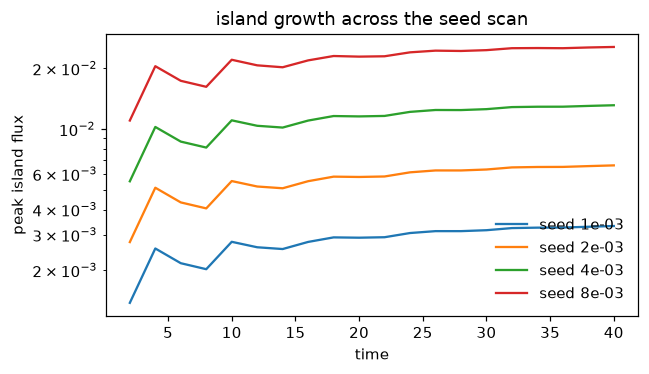

In [3]:
flux = np.asarray(result.trajectory.states.psi)
times = np.asarray(result.trajectory.times)
island = flux - flux.mean(axis=3, keepdims=True)
amplitude_history = np.abs(island).max(axis=(2, 3))

figure, axis = plt.subplots(figsize=(6, 3.5), dpi=110)
for case, seed in enumerate(amplitudes):
    axis.semilogy(times, amplitude_history[case], label=f"seed {seed:.0e}")
axis.set_xlabel("time")
axis.set_ylabel("peak island flux")
axis.legend(frameon=False)
axis.set_title("island growth across the seed scan")
figure.tight_layout()

The four curves keep their ordering: larger seeds give larger islands, with
the same growth rate in the linear phase. That is the expected linear-theory
behavior, and deviations at the largest seed mark the start of the
nonlinear regime.

For one large trajectory instead of many cases, shard the field with
`device_count` on a plain `run()`. The
[device guide](../how_to/run_on_gpus.md) covers both modes, multi-process
runs, and the measured scaling.